In [16]:
import json
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

COLLECTION_DATE = date.today().isoformat()

In [ ]:
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW = ROOT / "raw"
ARCHIVE = RAW / "archive"
ARCHIVE_META = ARCHIVE / "metadata"
BRONZE = ROOT / "bronze"
GOLD_MED = ROOT / "gold" / "analise_medalhas"
GOLD_MOD = ROOT / "gold" / "analise_modalidades"
GOLD_GEN = ROOT / "gold" / "analise_genero"

for p in (ARCHIVE_META, BRONZE, GOLD_MED, GOLD_MOD, GOLD_GEN):
    p.mkdir(parents=True, exist_ok=True)

print("Raiz do projeto:", ROOT)
print("Bronze:", BRONZE)

Raiz do projeto: C:\Users\eduar\Atividade-Ciencia-Dados2
Bronze: C:\Users\eduar\Atividade-Ciencia-Dados2\bronze


In [18]:
def escrever_json(caminho: Path, dados: dict) -> None:
    caminho.parent.mkdir(parents=True, exist_ok=True)
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(dados, f, indent=2, ensure_ascii=False)


def metadado_dataset(nome: str, fonte: str, descricao: str, campos: dict, observacoes: str) -> dict:
    return {
        "dataset_name": nome,
        "source": fonte,
        "description": descricao,
        "fields": campos,
        "collection_date": COLLECTION_DATE,
        "observations": observacoes,
    }


def carregar_todos_csvs(pasta: Path) -> dict[str, pd.DataFrame]:
    """Carrega todos os CSVs de uma pasta."""
    dados = {}
    for arquivo in sorted(pasta.glob("*.csv")):
        nome = arquivo.stem
        try:
            df = pd.read_csv(arquivo, low_memory=False)
            dados[nome] = df
            print(f"OK {nome}: {len(df)} linhas")
        except Exception as e:
            print(f"Erro em {nome}: {e}")
    return dados


def salvar_bronze_parquet(df: pd.DataFrame, nome_arquivo: str, meta: dict) -> None:
    pq = BRONZE / f"{nome_arquivo}.parquet"
    js = BRONZE / f"{nome_arquivo}.json"
    df.to_parquet(pq, index=False)
    escrever_json(js, meta)
    print(f"Bronze: {pq.name} + {js.name}")

In [ ]:
FONTES_ARCHIVE = "Paris 2024 / Olympics.com — dados abertos"
FONTES_WO = "World Olympedia — medal tally export"

DESCRICOES = {
    "athletes": ("Cadastro de atletas Paris 2024.", {"gender": "Sexo", "country_code": "NOC", "disciplines": "Modalidades"}),
    "medals": ("Medalhas por prova (linha por medalha).", {"medal_type": "Tipo", "discipline": "Modalidade", "event": "Evento", "country_code": "NOC"}),
    "events": ("Catálogo de eventos por esporte.", {"event": "Evento", "sport": "Esporte", "sport_code": "Código"}),
    "medallists": ("Medalhistas detalhados.", {"country_code": "NOC", "medal_type": "Medalha", "event": "Evento"}),
    "medals_total": ("Totais por país Paris 2024.", {"country_code": "NOC", "Gold Medal": "Ouro", "Total": "Total"}),
    "nocs": ("Comitês olímpicos nacionais.", {"code": "NOC", "country": "País"}),
    "world_olympedia_olympics_game_medal_tally": ("Medalhas históricas por edição e NOC.", {"year": "Ano", "country_noc": "NOC", "gold": "Ouro"}),
}

dfs = carregar_todos_csvs(ARCHIVE)
print(f"\nTotal de tabelas em archive: {len(dfs)}")

for stem, df in dfs.items():
    cols = list(df.columns)
    if stem in DESCRICOES:
        desc, campos_base = DESCRICOES[stem]
        fonte = FONTES_WO if "world_olympedia" in stem else FONTES_ARCHIVE
        campos = {c: f"Coluna: {c}" for c in cols}
        for k, v in campos_base.items():
            if k in cols:
                campos[k] = v
    else:
        desc = f"Dataset {stem}."
        fonte = FONTES_ARCHIVE
        campos = {c: f"Coluna: {c}" for c in cols}
    meta = metadado_dataset(stem, fonte, desc, campos, "")
    escrever_json(ARCHIVE_META / f"{stem}.json", meta)

print("Metadados archive salvos em", ARCHIVE_META)

OK athletes: 11113 linhas
OK coaches: 974 linhas
OK events: 329 linhas
OK medallists: 2315 linhas
OK medals: 1044 linhas
OK medals_total: 92 linhas
OK nocs: 224 linhas
OK schedules: 3895 linhas
OK schedules_preliminary: 2298 linhas
OK teams: 1698 linhas
OK technical_officials: 1021 linhas
OK torch_route: 73 linhas
OK venues: 35 linhas
OK world_olympedia_olympics_game_medal_tally: 1807 linhas

Total de tabelas em archive: 14
Metadados archive salvos em C:\Users\eduar\Atividade-Ciencia-Dados2\raw\archive\metadata


In [20]:
# Bronze: converter cada CSV de raw/archive para Parquet + metadados em bronze/
for stem, df in dfs.items():
    meta = metadado_dataset(
        f"bronze_{stem}",
        f"Conversão Parquet de raw/archive/{stem}.csv",
        f"Snapshot tabular de {stem}.",
        {c: f"Coluna: {c}" for c in df.columns},
        "Gerado a partir do notebook processamento.ipynb",
    )
    salvar_bronze_parquet(df, stem, meta)

Bronze: athletes.parquet + athletes.json
Bronze: coaches.parquet + coaches.json
Bronze: events.parquet + events.json
Bronze: medallists.parquet + medallists.json
Bronze: medals.parquet + medals.json
Bronze: medals_total.parquet + medals_total.json
Bronze: nocs.parquet + nocs.json
Bronze: schedules.parquet + schedules.json
Bronze: schedules_preliminary.parquet + schedules_preliminary.json
Bronze: teams.parquet + teams.json
Bronze: technical_officials.parquet + technical_officials.json
Bronze: torch_route.parquet + torch_route.json
Bronze: venues.parquet + venues.json
Bronze: world_olympedia_olympics_game_medal_tally.parquet + world_olympedia_olympics_game_medal_tally.json


In [21]:
# Integrações (JOINs / agregações) → bronze com metadados

# 1) Medalhas históricas + Paris 2024 (mesmo esquema de colunas)
hist_path = RAW / "olympics_historico.csv"
if not hist_path.exists():
    hist_path = ARCHIVE / "world_olympedia_olympics_game_medal_tally.csv"
paris_path = RAW / "olympics_paris2024.csv"
if not paris_path.exists():
    paris_path = ARCHIVE / "medals_total.csv"
hist = pd.read_csv(hist_path, low_memory=False)
paris = pd.read_csv(paris_path, low_memory=False)
paris_norm = pd.DataFrame(
    {
        "year": 2024,
        "edition": "2024 Summer Olympics",
        "edition_id": pd.NA,
        "country": paris["country"],
        "country_noc": paris["country_code"],
        "gold": paris["Gold Medal"],
        "silver": paris["Silver Medal"],
        "bronze": paris["Bronze Medal"],
        "total": paris["Total"],
    }
)
medalhas_uni = pd.concat([hist, paris_norm], ignore_index=True)
salvar_bronze_parquet(
    medalhas_uni,
    "medalhas_1896_2024",
    metadado_dataset(
        "medalhas_1896_2024",
        "World Olympedia + Paris 2024 medals_total",
        "Medalhas por ano e NOC; 2024 incorporado do quadro oficial Paris 2024.",
        {
            "year": "Ano",
            "edition": "Edição",
            "country_noc": "NOC",
            "gold": "Ouro",
            "silver": "Prata",
            "bronze": "Bronze",
            "total": "Total",
        },
        "edition_id pode ser nulo para 2024.",
    ),
)

# 2) JOIN medalhas × eventos (enriquecimento por nome do evento)
medals_df = dfs["medals"]
events_df = dfs["events"]
modalidades_join = medals_df.merge(events_df, on="event", how="left")
salvar_bronze_parquet(
    modalidades_join,
    "modalidades_1896_2024",
    metadado_dataset(
        "modalidades_1896_2024",
        "JOIN medals.csv × events.csv",
        "Medalhas Paris 2024 com sport_code, sport_url e tag do catálogo de eventos.",
        {c: f"Coluna: {c}" for c in modalidades_join.columns},
        "JOIN apenas sobre dados Paris 2024; nome do ficheiro segue padrão da atividade.",
    ),
)

# 3) Atletas por sexo
atletas = dfs["athletes"]
por_sexo = (
    atletas.groupby("gender", dropna=False).size().reset_index(name="quantidade_atletas")
)
salvar_bronze_parquet(
    por_sexo,
    "atletas_por_sexo",
    metadado_dataset(
        "atletas_por_sexo",
        "Agregação athletes.csv",
        "Contagem de atletas Paris 2024 por campo gender.",
        {"gender": "Sexo", "quantidade_atletas": "Contagem"},
        "",
    ),
)

Bronze: medalhas_1896_2024.parquet + medalhas_1896_2024.json
Bronze: modalidades_1896_2024.parquet + modalidades_1896_2024.json
Bronze: atletas_por_sexo.parquet + atletas_por_sexo.json


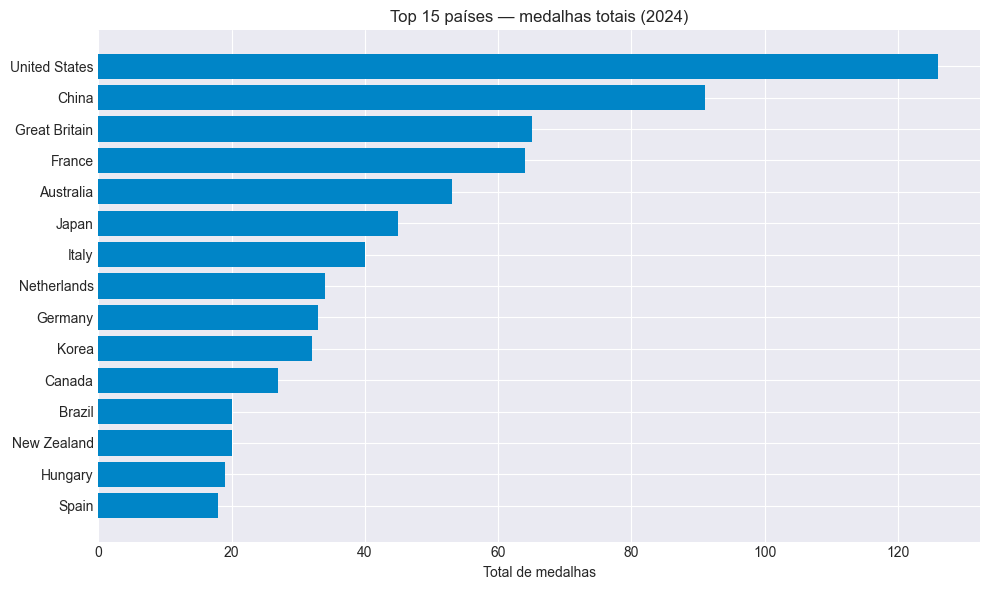

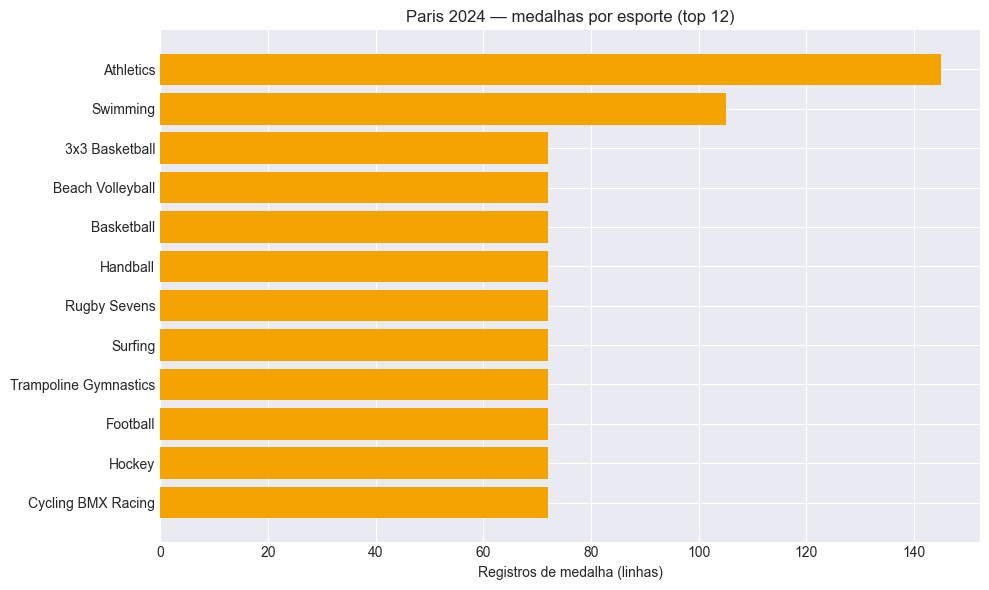

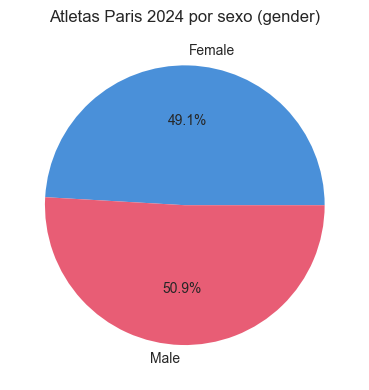

Gold atualizado em C:\Users\eduar\Atividade-Ciencia-Dados2\gold\analise_medalhas C:\Users\eduar\Atividade-Ciencia-Dados2\gold\analise_modalidades C:\Users\eduar\Atividade-Ciencia-Dados2\gold\analise_genero


In [22]:
# Gold: quadro de medalhas (ano mais recente), gráfico e pastas analise_modalidades / analise_genero
ultimo_ano = int(medalhas_uni["year"].max())
resumo_med = (
    medalhas_uni[medalhas_uni["year"] == ultimo_ano]
    .groupby(["country_noc", "country"], as_index=False)[["gold", "silver", "bronze", "total"]]
    .sum()
    .sort_values("total", ascending=False)
)
resumo_med.to_csv(GOLD_MED / "medalhas_summary.csv", index=False)

top = resumo_med.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top["country"][::-1], top["total"][::-1], color="#0085C7")
ax.set_xlabel("Total de medalhas")
ax.set_title(f"Top 15 países — medalhas totais ({ultimo_ano})")
plt.tight_layout()
fig.savefig(GOLD_MED / "medalhas_plot.png", dpi=150)
plt.show()

escrever_json(
    GOLD_MED / "metadata.json",
    {
        "dataset_name": "analise_medalhas",
        "source": "bronze/medalhas_1896_2024",
        "description": "Resumo e visualização do quadro de medalhas do ano mais recente.",
        "fields": {
            "country_noc": "NOC",
            "country": "País",
            "gold": "Ouro",
            "silver": "Prata",
            "bronze": "Bronze",
            "total": "Total",
        },
        "collection_date": COLLECTION_DATE,
        "observations": f"medalhas_summary.csv e medalhas_plot.png para o ano {ultimo_ano}.",
        "files": {
            "medalhas_summary.csv": "Ranking por país",
            "medalhas_plot.png": "Gráfico top 15",
        },
    },
)

# Modalidades: contagem de linhas de medalha por esporte
mod_summary = (
    modalidades_join.groupby("sport", as_index=False)
    .size()
    .rename(columns={"size": "num_medalhas_registradas"})
    .sort_values("num_medalhas_registradas", ascending=False)
)
mod_summary.to_csv(GOLD_MOD / "modalidades_summary.csv", index=False)
top_m = mod_summary.head(12)
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.barh(top_m["sport"][::-1], top_m["num_medalhas_registradas"][::-1], color="#F4A300")
ax2.set_xlabel("Registros de medalha (linhas)")
ax2.set_title("Paris 2024 — medalhas por esporte (top 12)")
plt.tight_layout()
fig2.savefig(GOLD_MOD / "modalidades_plot.png", dpi=150)
plt.show()

escrever_json(
    GOLD_MOD / "metadata.json",
    metadado_dataset(
        "analise_modalidades",
        "bronze/modalidades_1896_2024",
        "Distribuição de linhas de medalha por esporte (Paris 2024).",
        {"sport": "Esporte", "num_medalhas_registradas": "Contagem de linhas"},
        "Cada linha no bronze é uma medalha individual.",
    ),
)

por_sexo.to_csv(GOLD_GEN / "genero_summary.csv", index=False)
fig3, ax3 = plt.subplots(figsize=(6, 4))
cores = ["#4a90d9", "#e85d75"] if len(por_sexo) == 2 else None
ax3.pie(
    por_sexo["quantidade_atletas"],
    labels=por_sexo["gender"],
    autopct="%1.1f%%",
    colors=cores,
)
ax3.set_title("Atletas Paris 2024 por sexo (gender)")
plt.tight_layout()
fig3.savefig(GOLD_GEN / "genero_plot.png", dpi=150)
plt.show()

escrever_json(
    GOLD_GEN / "metadata.json",
    metadado_dataset(
        "analise_genero",
        "bronze/atletas_por_sexo",
        "Proporção de atletas por sexo na base oficial Paris 2024.",
        {"gender": "Sexo", "quantidade_atletas": "Quantidade"},
        "",
    ),
)

print("Gold atualizado em", GOLD_MED, GOLD_MOD, GOLD_GEN)

In [23]:
# Verificação rápida
print(medalhas_uni.tail(3))
print(modalidades_join[["event", "sport", "medal_type"]].head(3))
print(por_sexo)

      year               edition edition_id    country country_noc  gold  \
1896  2024  2024 Summer Olympics       <NA>  Singapore         SGP     0   
1897  2024  2024 Summer Olympics       <NA>   Slovakia         SVK     0   
1898  2024  2024 Summer Olympics       <NA>     Zambia         ZAM     0   

      silver  bronze  total  
1896       0       1      1  
1897       0       1      1  
1898       0       1      1  
                         event         sport    medal_type
0  Men's Individual Time Trial  Cycling Road    Gold Medal
1  Men's Individual Time Trial  Cycling Road  Silver Medal
2  Men's Individual Time Trial  Cycling Road  Bronze Medal
   gender  quantidade_atletas
0  Female                5455
1    Male                5658
